<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/CNN_based_Auto_Enconde_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#Implementando as bibliotecas
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#transformação de imagem
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])
#conjunto de dados de treinamento e validação
trn_ds = MNIST('./content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('./content/', transform=img_transform, train=False, download=True)

batch_size = 128
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [22]:
#classe do autoencoder convolucional
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        #módulo codificador
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(True), #duas camadas convulacionas
            nn.MaxPool2d(2, stride=2), # ducas camadas max pooling
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)
        )
        #módulo codificador
        self.decoder = nn.Sequential(
            #três camadas convolicionais transpostas
            nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 5, stride=2, padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh()
        )
        #modelo forward
    def forward(self, x):
        x = self.encoder(x) #imagem de entrada
        x = self.decoder(x)
        return x
model = ConvAutoEncoder().to(device)
!pip install torch_summary
from torchsummary import summary # biblioteca utilizada para imprimir resumo da arquitetura do modelo
summary(model, torch.zeros(2, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 3, 3]            --
|    └─Conv2d: 2-1                       [-1, 32, 14, 14]          320
|    └─ReLU: 2-2                         [-1, 32, 14, 14]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 7, 7]            --
|    └─Conv2d: 2-4                       [-1, 64, 4, 4]            18,496
|    └─ReLU: 2-5                         [-1, 64, 4, 4]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 3, 3]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 7, 7]            18,464
|    └─ReLU: 2-8                         [-1, 32, 7, 7]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 3, 3]            --
|    └─Conv2d: 2-1                       [-1, 32, 14, 14]          320
|    └─ReLU: 2-2                         [-1, 32, 14, 14]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 7, 7]            --
|    └─Conv2d: 2-4                       [-1, 64, 4, 4]            18,496
|    └─ReLU: 2-5                         [-1, 64, 4, 4]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 3, 3]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 7, 7]            18,464
|    └─ReLU: 2-8                         [-1, 32, 7, 7]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

In [23]:
# função de treinamento do modelo
def train_batch(input,model,criterion,optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

In [24]:
# essa função já avalia o modelo em um lote
@torch.no_grad()
def validate_batch(input,model,criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

In [25]:
model = ConvAutoEncoder().to(device) #função de perda como erro quadrático médio
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay=1e-5) #optimizador Adam, com taxa de aprendizado

In [26]:
#modelo percorre por 5 épocas
num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
  N = len(trn_dl)
  for ix, (data, _) in enumerate(trn_dl):
    loss = train_batch(data, model, criterion, optimizer) # treina o modeo para cada lote
    log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r') # redefine a perda de treinamento e validação

  N = len(val_dl)
  for ix, (data, _) in enumerate(val_dl):
    loss = validate_batch(data, model, criterion)
    log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='/r')

  log.report_avgs(epoch+1)

EPOCH: 1.000  val_loss: 0.049  trn_loss: 0.149  (56.19s - 224.76s remaining)
EPOCH: 2.000  val_loss: 0.034  trn_loss: 0.041  (111.74s - 167.60s remaining)
EPOCH: 3.000  val_loss: 0.028  trn_loss: 0.032  (163.16s - 108.77s remaining)
EPOCH: 4.000  val_loss: 0.026  trn_loss: 0.028  (209.05s - 52.26s remaining)
EPOCH: 5.000  val_loss: 0.023  trn_loss: 0.025  (256.72s - 0.00s remaining)


100%|██████████| 106/106 [00:00<00:00, 1977.83it/s]


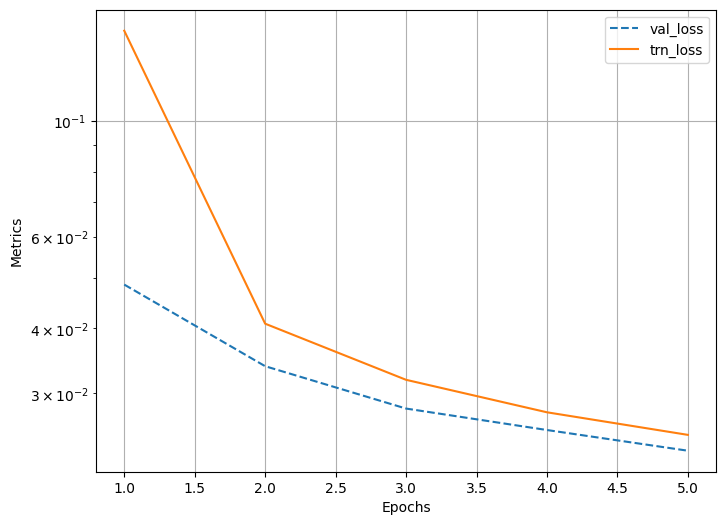

In [27]:
log.plot_epochs(log=True)

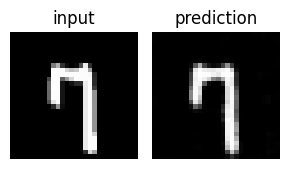

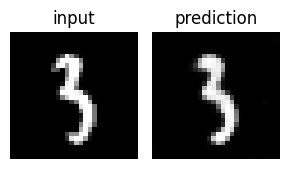

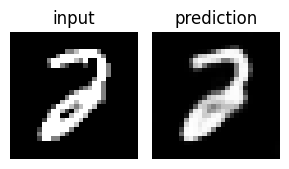

In [28]:
import matplotlib.pyplot as plt
model.eval()
#exibe imagens de conjuntos de dados de validação
for _ in range(3): # selecioanando apenas 3 imagens
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    im = im.to(device)
    _im = model(im[None])[0].cpu()
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0].cpu(), ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

In [29]:
latent_vectors = []
classes = []

In [30]:
# extrai vetores latentes do conjunto de dados de validação
for im, clss in val_dl:
    im = im.to(device)
    with torch.no_grad():
        latent = model.encoder(im).view(im.size(0), -1)
    latent_vectors.append(latent.cpu())
    classes.append(clss)

In [31]:
latent_vectors = torch.cat(latent_vectors) # módulo codificador do modelo

In [32]:
from sklearn.manifold import TSNE
tsne = TSNE(2)

In [34]:
clustered = tsne.fit_transform(latent_vectors.numpy()) # vizualizar os vetores latentes

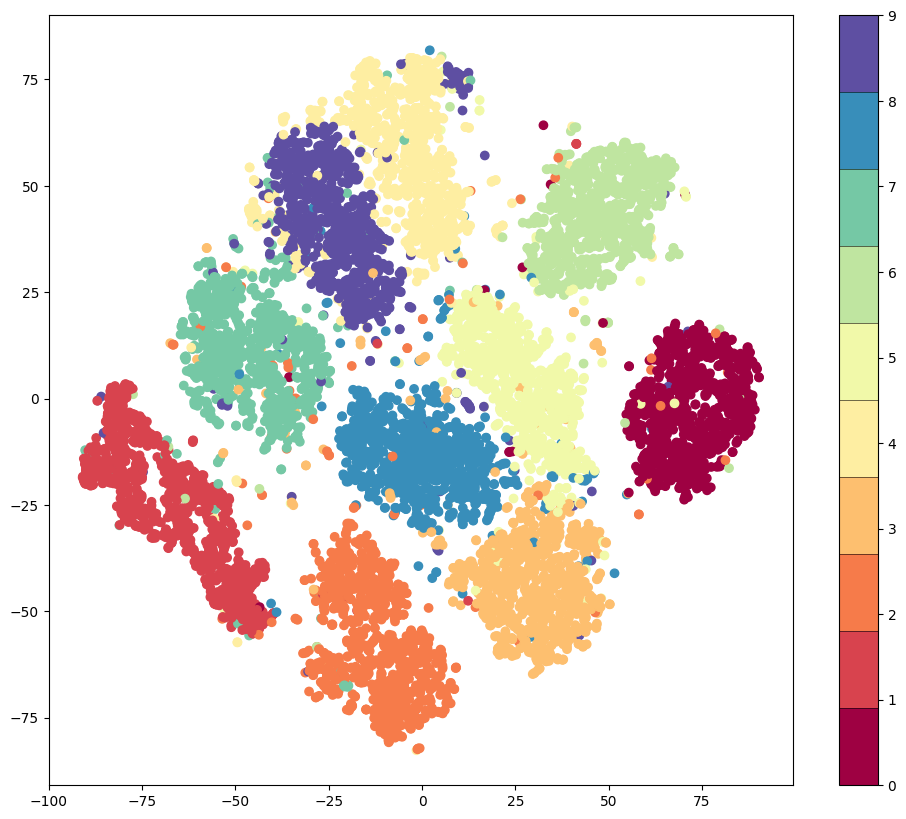

In [35]:
fig = plt.figure(figsize=(12, 10))
cmap = plt.get_cmap('Spectral', 10)
all_classes = torch.cat(classes).numpy()
plt.scatter(*zip(*clustered), c=all_classes, cmap=cmap)
plt.colorbar(drawedges=True)

In [41]:
latent_vectors = []
classes = []
for im,clss in val_dl:
    latent_vectors.append(model.encoder(im))
    classes.extend(clss)
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy().reshape(10000, -1)

In [42]:
rand_vectors = []
for col in latent_vectors.transpose(1,0):
    mu, sigma = col.mean(), col.std()
    rand_vectors.append(sigma*torch.randn(1,576) + mu)

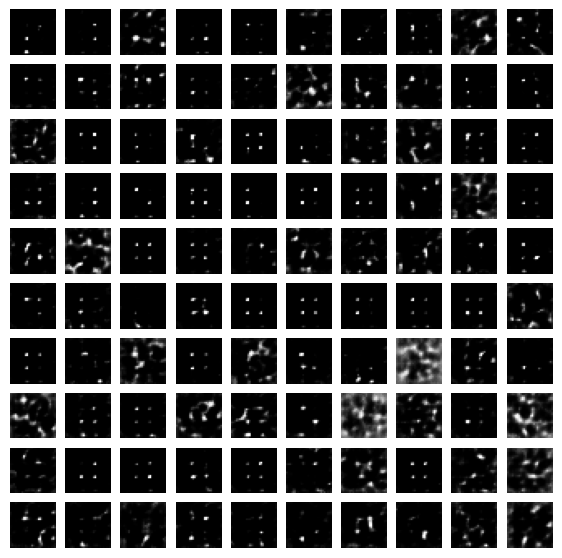

In [44]:
#gera alguns vetores aleatórios
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat)
for p in rand_vectors[:100]:
    img = model.decoder(p.reshape(1,64,3,3)).view(28,28) # modelo decodificador
    show(img, ax=next(ax)) # seleciona aleatoriamente 100 vetores do espaço latente